# TechMind — Notebook de Ciência de Dados

**Objetivo:** treinar um modelo de classificação temática de conteúdos técnicos (artigos, documentações, anotações de estudo) que receba um **título** e um **texto**, e retorne:

- `categoria` (Backend, Frontend, Data Science, DevOps, Mobile ou Cloud)
- `probabilidade` da categoria prevista
- `informacoes_adicionais` (palavras-chave extraídas do conteúdo)

Este notebook segue a estrutura esperada pelo hackathon:

1. Geração/carregamento da base de dados
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento de texto
4. Vetorização (TF-IDF) e split treino/teste
5. Treinamento do modelo
6. Avaliação do modelo
7. Extração de palavras-chave
8. Função de predição completa (simula o endpoint `POST /conteudo`)
9. Testes com exemplos
10. Serialização do modelo (joblib)

> **Nota sobre os dados:** como o time ainda não possui uma base própria de conteúdos técnicos, este notebook **gera uma base sintética** de exemplos (títulos + textos) para cada categoria-alvo. O código de geração fica isolado na Seção 1 — quando vocês tiverem uma base real (extraída de documentações, artigos ou anotações da equipe), basta substituir essa etapa por um `pd.read_csv(...)` carregando os dados reais, mantendo o resto do notebook igual.

In [1]:
import re
import string
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_colwidth', 120)


## 1. Geração da base de dados

Cada categoria possui uma lista de *subtemas* e um conjunto de *templates* de título/texto. Combinando subtemas + templates de forma aleatória geramos uma base sintética diversa, mas tematicamente coerente, para cada uma das 6 categorias-alvo do projeto.

In [2]:
SUBTOPICS = {
    "Backend": [
        "APIs REST", "Spring Boot", "Node.js e Express", "autenticação JWT",
        "arquitetura de microsserviços", "bancos de dados relacionais",
        "ORM e Hibernate", "mensageria com RabbitMQ", "GraphQL",
        "cache com Redis", "testes unitários em Java", "Clean Architecture",
        "versionamento de APIs", "tratamento de exceções em APIs"
    ],
    "Frontend": [
        "React.js", "componentes reutilizáveis", "gerenciamento de estado com Redux",
        "Vue.js", "CSS Grid e Flexbox", "acessibilidade web",
        "TypeScript no front-end", "performance de renderização",
        "Webpack e bundling", "design responsivo", "hooks do React", "Next.js",
        "consumo de APIs no front-end", "testes de componentes com Jest"
    ],
    "Data Science": [
        "análise exploratória de dados", "machine learning supervisionado",
        "processamento de linguagem natural", "pandas e manipulação de dados",
        "modelos de classificação", "engenharia de features",
        "visualização de dados", "redes neurais", "regressão logística",
        "clustering e agrupamento", "métricas de avaliação de modelos",
        "scikit-learn", "séries temporais", "validação cruzada"
    ],
    "DevOps": [
        "integração contínua", "pipelines de CI/CD", "containers com Docker",
        "orquestração com Kubernetes", "infraestrutura como código",
        "monitoramento e observabilidade", "Terraform", "automação de deploy",
        "Jenkins", "GitOps", "escalabilidade de infraestrutura",
        "logs centralizados", "gestão de segredos", "blue-green deployment"
    ],
    "Mobile": [
        "desenvolvimento com Flutter", "aplicativos Android nativos",
        "Swift e iOS", "React Native", "UI mobile responsiva",
        "notificações push", "armazenamento local em apps",
        "ciclo de vida de atividades Android", "publicação na Play Store",
        "consumo de APIs REST em apps móveis", "performance de aplicativos móveis",
        "Kotlin", "testes de interface em apps", "modo offline em aplicativos"
    ],
    "Cloud": [
        "computação em nuvem", "armazenamento em nuvem (Object Storage)",
        "OCI Compute", "serverless e Functions", "escalabilidade automática",
        "redes virtuais na nuvem", "segurança em ambientes cloud",
        "migração para a nuvem", "provedores AWS e Azure",
        "custos e otimização em cloud", "bancos de dados gerenciados na nuvem",
        "alta disponibilidade", "balanceamento de carga na nuvem",
        "backup e recuperação de desastres"
    ],
}

TITLE_TEMPLATES = [
    "Introdução a {t1}",
    "Como funciona {t1}",
    "Boas práticas em {t1}",
    "Guia completo sobre {t1}",
    "Entendendo {t1} na prática",
    "{t1}: conceitos essenciais",
    "Um panorama sobre {t1}",
    "Primeiros passos com {t1}",
]

TEXT_TEMPLATES = [
    "Este conteúdo apresenta os principais conceitos sobre {t1}. São abordados temas "
    "como {t2} e {t3}, além de exemplos práticos de aplicação no dia a dia de "
    "desenvolvimento. O objetivo é fornecer uma base sólida para quem deseja "
    "aprofundar conhecimentos em {t1}.",

    "Neste material, discutimos {t1} com foco em aplicações reais. Também são "
    "explorados aspectos relacionados a {t2}, com dicas de boas práticas e "
    "armadilhas comuns. Ao final, o leitor terá uma visão prática sobre {t3}.",

    "Um estudo detalhado sobre {t1}, cobrindo desde os fundamentos até tópicos mais "
    "avançados como {t2}. O texto também relaciona {t1} com {t3}, mostrando como "
    "esses conceitos se conectam em projetos do mundo real.",

    "Esta documentação técnica explica {t1} passo a passo, com exemplos de código "
    "e cenários de uso. Também é discutida a relação entre {t2} e {t3}, "
    "reforçando quando cada abordagem deve ser utilizada.",

    "Notas de estudo sobre {t1}: principais definições, vantagens e desvantagens. "
    "O conteúdo também compara {t1} com {t2} e apresenta um exemplo prático "
    "envolvendo {t3} para fixar o aprendizado.",

    "Tutorial prático que ensina {t1} do zero. Ao longo do texto, também são "
    "apresentados conceitos de {t2}, e ao final é proposto um exercício "
    "envolvendo {t3} para consolidar o conteúdo.",
]

N_PER_CATEGORY = 60

def generate_dataset():
    rows = []
    for categoria, subtopics in SUBTOPICS.items():
        for _ in range(N_PER_CATEGORY):
            t1, t2, t3 = random.sample(subtopics, 3)
            title = random.choice(TITLE_TEMPLATES).format(t1=t1)
            text = random.choice(TEXT_TEMPLATES).format(t1=t1, t2=t2, t3=t3)
            rows.append({"titulo": title, "texto": text, "categoria": categoria})
    df = pd.DataFrame(rows)
    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    return df

df = generate_dataset()
df.to_csv("techmind_dataset.csv", index=False)
print(f"Base gerada com {len(df)} registros ({df['categoria'].nunique()} categorias).")
df.head()


Base gerada com 360 registros (6 categorias).


,titulo,texto,categoria
0,Como funciona Jenkins,"Um estudo detalhado sobre Jenkins, cobrindo desde os fundamentos até tópicos mais avançados como logs centralizados....",DevOps
1,Guia completo sobre versionamento de APIs,"Tutorial prático que ensina versionamento de APIs do zero. Ao longo do texto, também são apresentados conceitos de C...",Backend
2,Boas práticas em testes de interface em apps,"Notas de estudo sobre testes de interface em apps: principais definições, vantagens e desvantagens. O conteúdo també...",Mobile
3,Primeiros passos com custos e otimização em cloud,"Notas de estudo sobre custos e otimização em cloud: principais definições, vantagens e desvantagens. O conteúdo tamb...",Cloud
4,Guia completo sobre Node.js e Express,Este conteúdo apresenta os principais conceitos sobre Node.js e Express. São abordados temas como arquitetura de mic...,Backend


## 2. Análise Exploratória de Dados (EDA)

In [3]:
df['categoria'].value_counts()

categoria
DevOps          60
Backend         60
Mobile          60
Cloud           60
Data Science    60
Frontend        60
Name: count, dtype: int64

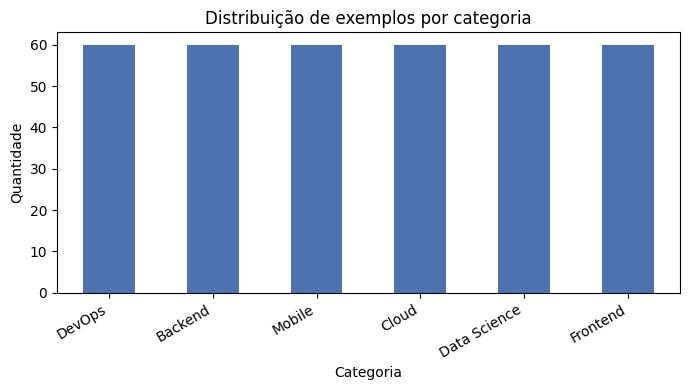

In [4]:
plt.figure(figsize=(7,4))
df['categoria'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title('Distribuição de exemplos por categoria')
plt.ylabel('Quantidade')
plt.xlabel('Categoria')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


        texto_len  titulo_len
count  360.000000  360.000000
mean   268.641667   40.138889
std     33.838745    8.877228
min    201.000000   19.000000
25%    243.000000   34.000000
50%    262.500000   40.000000
75%    286.000000   47.000000
max    378.000000   61.000000


<Figure size 700x400 with 0 Axes>

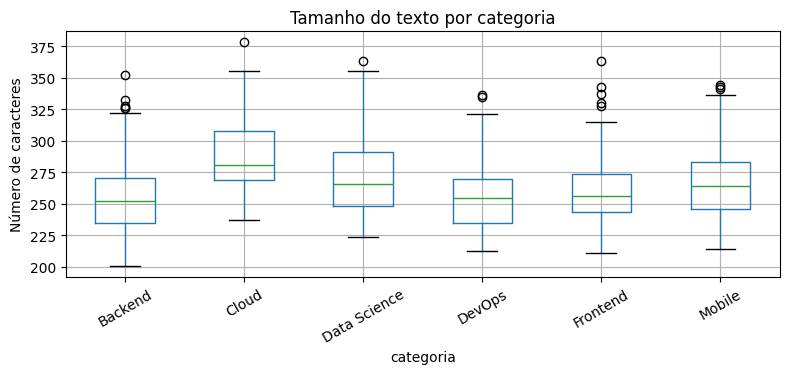

In [5]:
df['texto_len'] = df['texto'].str.len()
df['titulo_len'] = df['titulo'].str.len()

print(df[['texto_len', 'titulo_len']].describe())

plt.figure(figsize=(7,4))
df.boxplot(column='texto_len', by='categoria', figsize=(8,4), rot=30)
plt.title('Tamanho do texto por categoria')
plt.suptitle('')
plt.ylabel('Número de caracteres')
plt.tight_layout()
plt.show()


In [6]:
# Palavras mais frequentes por categoria (visão inicial, ainda sem pré-processamento)
def top_words_raw(texts, n=8):
    words = re.findall(r"[a-zA-ZÀ-ÿ]+", " ".join(texts).lower())
    return Counter(words).most_common(n)

for categoria in df['categoria'].unique():
    textos_cat = df.loc[df['categoria'] == categoria, 'texto']
    print(f"\n{categoria}: {top_words_raw(textos_cat)}")



DevOps: [('de', 147), ('e', 79), ('com', 75), ('o', 59), ('também', 51), ('como', 49), ('a', 39), ('sobre', 38)]

Backend: [('de', 137), ('e', 97), ('com', 75), ('o', 66), ('em', 60), ('também', 49), ('sobre', 43), ('apis', 39)]

Mobile: [('de', 164), ('e', 89), ('o', 66), ('em', 64), ('com', 58), ('também', 53), ('aplicativos', 53), ('android', 43)]

Cloud: [('e', 131), ('de', 122), ('em', 102), ('nuvem', 93), ('o', 65), ('a', 52), ('também', 50), ('com', 49)]

Data Science: [('de', 191), ('e', 105), ('o', 56), ('dados', 54), ('também', 51), ('com', 50), ('como', 41), ('sobre', 40)]

Frontend: [('de', 127), ('e', 102), ('com', 79), ('o', 62), ('também', 49), ('js', 46), ('no', 46), ('sobre', 44)]


## 3. Pré-processamento de texto

Etapas aplicadas:
- conversão para minúsculas
- remoção de acentuação
- remoção de pontuação e números
- remoção de *stopwords* em português (lista própria, sem dependência de download externo)


In [7]:
STOPWORDS_PT = set("""
a ao aos aquela aquelas aquele aqueles aquilo as até com como da das de dela
delas dele deles depois do dos e ela elas ele eles em entre era essa essas
esse esses esta estas este estes eu foi for foram fosse fossem grande isso
isto já lhe lhes lo mais mas me mesmo meu meus minha minhas muito na nas nao
não nem no nos nossa nossas nosso nossos num numa não o os ou para pela
pelas pelo pelos por qual quando que quem se sem seu seus somos sua suas tal
também te tem tendo ter teu teus tu tua tuas um uma umas uns você vocês só
sao são também tais este estes esta estas isso aquilo onde sobre sob ate
""".split())

def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def clean_text(text):
    text = text.lower()
    text = remove_accents(text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_PT and len(t) > 2]
    return " ".join(tokens)

df['texto_limpo'] = df['texto'].apply(clean_text)
df['titulo_limpo'] = df['titulo'].apply(clean_text)

# Combina título + texto como entrada final do modelo (título costuma ser bem informativo)
df['conteudo_completo'] = df['titulo_limpo'] + " " + df['texto_limpo']

print("Antes:", df['texto'].iloc[0][:120], "...")
print("\nDepois:", df['texto_limpo'].iloc[0][:120], "...")


Antes: Um estudo detalhado sobre Jenkins, cobrindo desde os fundamentos até tópicos mais avançados como logs centralizados. O t ...

Depois: estudo detalhado jenkins cobrindo desde fundamentos topicos avancados logs centralizados texto tambem relaciona jenkins  ...


## 4. Vetorização (TF-IDF) e split treino/teste

In [8]:
X = df['conteudo_completo']
y = df['categoria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Treino:", X_train_tfidf.shape)
print("Teste:", X_test_tfidf.shape)


Treino: (288, 2083)
Teste: (72, 2083)


## 5. Treinamento do modelo

Comparamos três algoritmos clássicos e simples de treinar/explicar, bons para classificação de texto com poucos dados: Regressão Logística, Naive Bayes e SVM Linear.

In [9]:
models = {
    "Regressao Logistica": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Naive Bayes": MultinomialNB(),
    "SVM Linear": LinearSVC(random_state=RANDOM_SEED),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: acuracia = {acc:.3f}")


Regressao Logistica: acuracia = 1.000
Naive Bayes: acuracia = 1.000
SVM Linear: acuracia = 1.000


In [10]:
best_model_name = max(results, key=results.get)
print(f"Melhor modelo: {best_model_name} (acuracia = {results[best_model_name]:.3f})")

# Regressão Logística é escolhida preferencialmente quando o desempenho é
# equivalente, pois expõe probabilidades por classe (necessário para o
# campo `probabilidade` da resposta da API).
model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train_tfidf, y_train)


Melhor modelo: Regressao Logistica (acuracia = 1.000)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 6. Avaliação do modelo

In [11]:
y_pred = model.predict(X_test_tfidf)

print("Acuracia:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))


Acuracia: 1.0

              precision    recall  f1-score   support

     Backend       1.00      1.00      1.00        12
       Cloud       1.00      1.00      1.00        12
Data Science       1.00      1.00      1.00        12
      DevOps       1.00      1.00      1.00        12
    Frontend       1.00      1.00      1.00        12
      Mobile       1.00      1.00      1.00        12

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



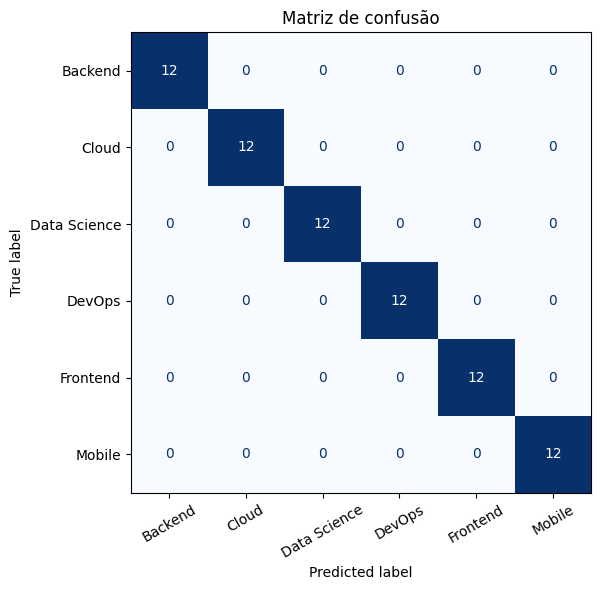

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=30, colorbar=False)
plt.title('Matriz de confusão')
plt.tight_layout()
plt.show()


## 7. Extração de palavras-chave

Para o campo `informacoes_adicionais`, extraímos os termos com maior peso TF-IDF dentro do próprio texto de entrada (as palavras mais "características" daquele conteúdo específico, e não apenas as mais frequentes).

In [13]:
feature_names = np.array(vectorizer.get_feature_names_out())

def extract_keywords(cleaned_text, top_n=5):
    vec = vectorizer.transform([cleaned_text])
    scores = vec.toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    keywords = [feature_names[i] for i in top_idx if scores[i] > 0]
    return keywords

# Exemplo
exemplo_idx = 0
print("Texto:", df['conteudo_completo'].iloc[exemplo_idx][:150])
print("Palavras-chave:", extract_keywords(df['conteudo_completo'].iloc[exemplo_idx]))


Texto: funciona jenkins estudo detalhado jenkins cobrindo desde fundamentos topicos avancados logs centralizados texto tambem relaciona jenkins containers do
Palavras-chave: ['jenkins', 'avancados logs', 'centralizados texto', 'centralizados', 'logs']


## 8. Função de predição completa

Esta função simula exatamente o comportamento esperado do endpoint `POST /conteudo` da API:

**Entrada:** `titulo`, `texto`
**Saída:** `categoria`, `probabilidade`, `informacoes_adicionais`

O time de back-end poderá reproduzir esta mesma lógica na API, carregando os artefatos serializados na Seção 10 (`modelo.joblib` e `vectorizer.joblib`).

In [14]:
def predict_content(titulo, texto, top_n_keywords=5):
    titulo_limpo = clean_text(titulo)
    texto_limpo = clean_text(texto)
    conteudo = titulo_limpo + " " + texto_limpo

    conteudo_tfidf = vectorizer.transform([conteudo])

    categoria_prevista = model.predict(conteudo_tfidf)[0]
    probabilidades = model.predict_proba(conteudo_tfidf)[0]
    prob_dict = dict(zip(model.classes_, probabilidades))
    probabilidade = round(float(prob_dict[categoria_prevista]), 4)

    palavras_chave = extract_keywords(conteudo, top_n=top_n_keywords)

    return {
        "categoria": categoria_prevista,
        "probabilidade": probabilidade,
        "informacoes_adicionais": palavras_chave,
    }


## 9. Testes com exemplos (mínimo de três, conforme exigido no MVP)

In [15]:
exemplos = [
    {
        "titulo": "Introdução ao Spring Boot",
        "texto": "Neste conteúdo são apresentados os conceitos básicos para "
                  "criação de APIs REST utilizando Java e Spring Boot."
    },
    {
        "titulo": "Como usar hooks no React",
        "texto": "Este tutorial explica como utilizar useState e useEffect "
                  "para gerenciar estado e efeitos colaterais em componentes React."
    },
    {
        "titulo": "Pipeline de CI/CD com Docker e Kubernetes",
        "texto": "Este artigo mostra como configurar um pipeline de integração "
                  "contínua utilizando Docker para containerização e Kubernetes "
                  "para orquestração dos serviços em produção."
    },
    {
        "titulo": "Análise exploratória de dados com Pandas",
        "texto": "Aprenda técnicas de limpeza e exploração de dados utilizando "
                  "a biblioteca Pandas, incluindo tratamento de valores ausentes "
                  "e visualização de distribuições."
    },
]

for ex in exemplos:
    resultado = predict_content(ex["titulo"], ex["texto"])
    print("Entrada: ", ex)
    print("Saida:   ", resultado)
    print("-" * 90)


Entrada:  {'titulo': 'Introdução ao Spring Boot', 'texto': 'Neste conteúdo são apresentados os conceitos básicos para criação de APIs REST utilizando Java e Spring Boot.'}
Saida:    {'categoria': 'Backend', 'probabilidade': 0.7599, 'informacoes_adicionais': ['spring', 'spring boot', 'boot', 'rest', 'apis rest']}
------------------------------------------------------------------------------------------
Entrada:  {'titulo': 'Como usar hooks no React', 'texto': 'Este tutorial explica como utilizar useState e useEffect para gerenciar estado e efeitos colaterais em componentes React.'}
Saida:    {'categoria': 'Frontend', 'probabilidade': 0.5441, 'informacoes_adicionais': ['react', 'react tutorial', 'estado', 'hooks', 'hooks react']}
------------------------------------------------------------------------------------------
Entrada:  {'titulo': 'Pipeline de CI/CD com Docker e Kubernetes', 'texto': 'Este artigo mostra como configurar um pipeline de integração contínua utilizando Docker para co

## 10. Serialização do modelo

Salvamos o modelo treinado e o vetorizador TF-IDF com `joblib`, prontos para serem carregados pela API REST (Seção "Back-End" do projeto) e, opcionalmente, enviados para o **OCI Object Storage** como parte da integração com a nuvem.

In [16]:
joblib.dump(model, "modelo_classificacao.joblib")
joblib.dump(vectorizer, "vectorizer_tfidf.joblib")

print("Arquivos salvos:")
print(" - modelo_classificacao.joblib")
print(" - vectorizer_tfidf.joblib")
print(" - techmind_dataset.csv")


Arquivos salvos:
 - modelo_classificacao.joblib
 - vectorizer_tfidf.joblib
 - techmind_dataset.csv


In [17]:
# Teste de sanidade: recarregar os artefatos do zero e validar que a predição
# funciona de forma idêntica, exatamente como a API fará em produção.
model_reloaded = joblib.load("modelo_classificacao.joblib")
vectorizer_reloaded = joblib.load("vectorizer_tfidf.joblib")

def predict_with_reloaded_artifacts(titulo, texto, top_n_keywords=5):
    conteudo = clean_text(titulo) + " " + clean_text(texto)
    conteudo_tfidf = vectorizer_reloaded.transform([conteudo])
    categoria_prevista = model_reloaded.predict(conteudo_tfidf)[0]
    probabilidades = model_reloaded.predict_proba(conteudo_tfidf)[0]
    prob_dict = dict(zip(model_reloaded.classes_, probabilidades))
    probabilidade = round(float(prob_dict[categoria_prevista]), 4)
    palavras_chave = extract_keywords(conteudo, top_n=top_n_keywords)
    return {
        "categoria": categoria_prevista,
        "probabilidade": probabilidade,
        "informacoes_adicionais": palavras_chave,
    }

print(predict_with_reloaded_artifacts(
    "Introdução ao Spring Boot",
    "Neste conteúdo são apresentados os conceitos básicos para criação de "
    "APIs REST utilizando Java e Spring Boot."
))


{'categoria': 'Backend', 'probabilidade': 0.7599, 'informacoes_adicionais': ['spring', 'spring boot', 'boot', 'rest', 'apis rest']}


## Conclusão e próximos passos

- O modelo foi treinado sobre uma base **sintética** de 360 exemplos (60 por categoria). Assim que a equipe tiver uma base real (documentações, artigos, anotações), recomenda-se substituir a Seção 1 pelo carregamento desses dados reais — o restante do notebook não precisa mudar.
- Os artefatos `modelo_classificacao.joblib` e `vectorizer_tfidf.joblib` devem ser consumidos pela **API REST** do time de back-end, reproduzindo a função `predict_content`.
- Para a integração com **OCI**, os artefatos `.joblib` podem ser enviados para um bucket de **Object Storage**, de onde a API os baixa no startup (ou os carrega localmente, caso a API também rode em **OCI Compute**/**OCI Functions**).
- Melhorias futuras possíveis (itens opcionais do desafio): recomendação de conteúdos relacionados (similaridade de cosseno entre vetores TF-IDF), busca semântica, clustering de conteúdos similares e explicabilidade do modelo (pesos por termo).